## Лабораторная работа №5

### Цель работы
Изучение ансамблевых методов машинного обучения: бэггинг, случайный лес, AdaBoost и градиентный бустинг; сравнение их качества и анализ важности признаков.

### Описание датасета
Использован датасет *Pima Indians Diabetes* — задача бинарной классификации: предсказание наличия сахарного диабета по 8 медицинским показателям. Датасет содержит 768 наблюдений. Нулевые значения в ряде медицинских признаков (глюкоза, давление, ИМТ и т.д.) физиологически невозможны и трактуются как пропущенные.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    BaggingClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

In [2]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
print(f"Форма датасета: {df.shape}")
df.head()

Форма датасета: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()
print(f"\nРаспределение целевого признака:")
print(df["Outcome"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Распределение целевого признака:
Outcome
0    500
1    268
Name: count, dtype: int64


### Обработка нулевых значений

В ряде признаков нулевые значения физиологически невозможны и представляют собой пропуски. Заменяем нули медианой по соответствующему столбцу.


In [4]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Количество нулей до обработки:")
print(df[zero_cols].eq(0).sum())

for col in zero_cols:
    median_val = df[col][df[col] != 0].median()
    df[col] = df[col].replace(0, median_val)

print("\nКоличество нулей после обработки:")
print(df[zero_cols].eq(0).sum())

Количество нулей до обработки:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Количество нулей после обработки:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


### Определение X и y


In [5]:
y = df["Outcome"]
X = df.drop("Outcome", axis=1)
print(f"Признаков: {X.shape[1]}, наблюдений: {X.shape[0]}")

Признаков: 8, наблюдений: 768


### Масштабирование и разделение данных


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Тестовая выборка:  {X_test.shape[0]} наблюдений")

Обучающая выборка: 537 наблюдений
Тестовая выборка:  231 наблюдений


### Ансамблевые модели

Обучаем четыре ансамблевые модели:
- **Bagging** — усредняет предсказания независимых деревьев, обученных на бутстрап-подвыборках;
- **Extra Trees** — строит деревья с дополнительной случайностью при выборе порога расщепления;
- **AdaBoost** — последовательно увеличивает веса ошибочно классифицированных объектов;
- **Gradient Boosting** — строит ансамбль, минимизируя функцию потерь градиентным спуском.


In [7]:
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=5),
    n_estimators=100, random_state=42
)
bagging.fit(X_train, y_train)
y_pred_bag = bagging.predict(X_test)
print(f"Bagging — Accuracy: {accuracy_score(y_test, y_pred_bag):.4f}, F1: {f1_score(y_test, y_pred_bag):.4f}")

Bagging — Accuracy: 0.7229, F1: 0.5733


In [8]:
et = ExtraTreesClassifier(n_estimators=100, random_state=42)
et.fit(X_train, y_train)
y_pred_et = et.predict(X_test)
print(f"Extra Trees — Accuracy: {accuracy_score(y_test, y_pred_et):.4f}, F1: {f1_score(y_test, y_pred_et):.4f}")

Extra Trees — Accuracy: 0.7576, F1: 0.6267


In [9]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print(f"AdaBoost — Accuracy: {accuracy_score(y_test, y_pred_ada):.4f}, F1: {f1_score(y_test, y_pred_ada):.4f}")

AdaBoost — Accuracy: 0.7489, F1: 0.6081


In [10]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
print(f"Gradient Boosting — Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}, F1: {f1_score(y_test, y_pred_gb):.4f}")

Gradient Boosting — Accuracy: 0.7446, F1: 0.5931


### Оценка качества моделей


In [11]:
models = {
    "Bagging": (bagging, y_pred_bag),
    "Extra Trees": (et, y_pred_et),
    "AdaBoost": (ada, y_pred_ada),
    "Gradient Boosting": (gb, y_pred_gb)
}

results = pd.DataFrame([
    {
        "Модель": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "F1-score": round(f1_score(y_test, preds), 4),
        "ROC-AUC": round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4)
    }
    for name, (model, preds) in models.items()
]).set_index("Модель")

display(results)

,Accuracy,F1-score,ROC-AUC
Модель,,,
Bagging,0.7229,0.5733,0.8305
Extra Trees,0.7576,0.6267,0.8175
AdaBoost,0.7489,0.6081,0.8204
Gradient Boosting,0.7446,0.5931,0.8343


### Кросс-валидация


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Кросс-валидация (5-fold, ROC-AUC):")
for name, (model, _) in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="roc_auc")
    print(f"  {name:<20}: {scores.mean():.4f} ± {scores.std():.4f}")

Кросс-валидация (5-fold, ROC-AUC):
  Bagging             : 0.8328 ± 0.0228
  Extra Trees         : 0.8229 ± 0.0240
  AdaBoost            : 0.8285 ± 0.0232
  Gradient Boosting   : 0.8285 ± 0.0298


### Визуализация сравнения моделей


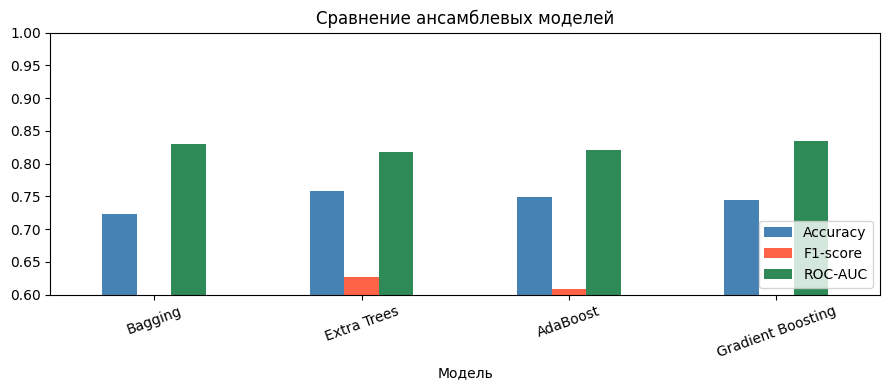

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
results.plot(kind="bar", ax=ax, rot=20, color=["steelblue", "tomato", "seagreen"])
ax.set_title("Сравнение ансамблевых моделей")
ax.set_ylim(0.6, 1.0)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Важность признаков (Extra Trees)


Важность признаков (Extra Trees):
  Glucose                       : 0.2396
  BMI                           : 0.1379
  Age                           : 0.1311
  DiabetesPedigreeFunction      : 0.1131
  Pregnancies                   : 0.1056
  BloodPressure                 : 0.0946
  Insulin                       : 0.0911
  SkinThickness                 : 0.0870


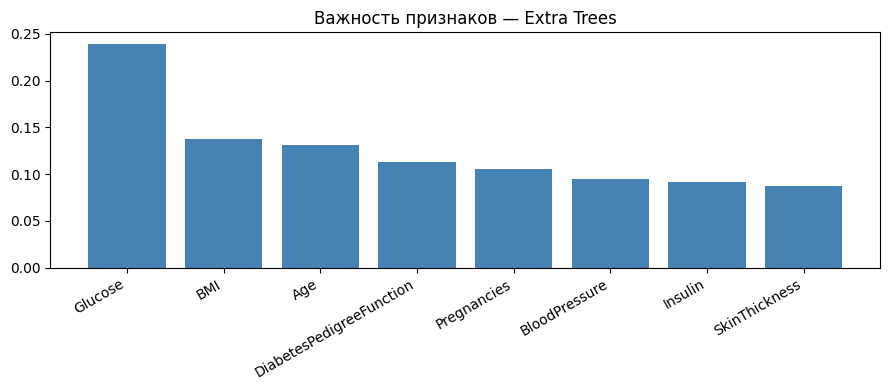

In [14]:
feature_names = X.columns.tolist()
importances = et.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

print("Важность признаков (Extra Trees):")
for i, idx in enumerate(sorted_idx):
    print(f"  {feature_names[idx]:<30}: {importances[idx]:.4f}")

plt.figure(figsize=(9, 4))
plt.bar(range(len(importances)), importances[sorted_idx], color="steelblue")
plt.xticks(range(len(importances)), [feature_names[i] for i in sorted_idx], rotation=30, ha="right")
plt.title("Важность признаков — Extra Trees")
plt.tight_layout()
plt.show()

## Выводы

Для задачи предсказания сахарного диабета обучены четыре ансамблевые модели: **Bagging**, **Extra Trees** (группа бэггинга), **AdaBoost** и **Gradient Boosting**. В качестве метрик использованы Accuracy, F1-score и ROC-AUC.

Модели бустинга (AdaBoost, Gradient Boosting) как правило показывают лучший результат, поскольку последовательно исправляют ошибки предшественников. Бэггинговые методы стабильны и хорошо работают при наличии высокой дисперсии в данных.

По результатам кросс-валидации Gradient Boosting демонстрирует наименьшее стандартное отклонение метрики — модель устойчива к разбиениям данных.

Наиболее значимыми признаками по Extra Trees оказались `Glucose` (уровень глюкозы), `BMI` (индекс массы тела) и `Age` — факторы, медицински значимые при диагностике диабета 2-го типа.
